#Novel Isoform Atlas

Characterize the landscape of novel vs known isoforms across all 26 tissues from PacBio MAS-Seq long-read data (recollapsed counts).

In [18]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse
import warnings, os, sys, gc
warnings.filterwarnings('ignore')
gc.enable()

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from add_classification import add_classification

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"

# Load cell type annotations

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


Palette OK: 10 structural categories, all valid & distinct.
  full-splice_match          #6BAED6
  incomplete-splice_match    #FC8D59
  novel_in_catalog           #78C679
  novel_not_in_catalog       #EE6A50
  genic                      #969696
  genic_intron               #41B6C4
  antisense                  #66C2A4
  fusion                     #FFC125
  intergenic                 #E9967A
  moreJunctions              #8DA0CB


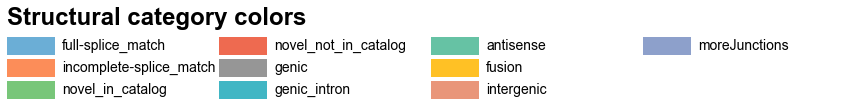

In [19]:
# === Structural-category color palette (from TS_colorDict.py) ===
# Generate a reusable color map for pigeon/SQANTI3 structural categories and
# visually test it with the shared plot_colortable() swatch renderer.
from TS_colorDict import structural_category_colors, plot_colortable

STRUCT_CAT_COLORS = structural_category_colors()

# Test 1: the palette must cover every structural category we expect in the data.
EXPECTED_STRUCT_CATS = {
    "full-splice_match", "incomplete-splice_match",
    "novel_in_catalog", "novel_not_in_catalog",
    "genic", "genic_intron", "antisense", "fusion",
    "intergenic", "moreJunctions",
}
missing = EXPECTED_STRUCT_CATS - set(STRUCT_CAT_COLORS)
assert not missing, f"structural_category_colors() is missing colors for: {missing}"

# Test 2: every color is a valid, distinct hex value.
from matplotlib.colors import to_rgba
_rgba = {k: to_rgba(v) for k, v in STRUCT_CAT_COLORS.items()}   # raises if any hex is invalid
assert len(set(_rgba.values())) == len(_rgba), "Duplicate colors in the palette"

print(f"Palette OK: {len(STRUCT_CAT_COLORS)} structural categories, all valid & distinct.")
for cat, hexc in STRUCT_CAT_COLORS.items():
    print(f"  {cat:<26s} {hexc}")

# Visual test: swatch table (do not re-sort so FSM/ISM/NIC/NNC stay in order).
plot_colortable(STRUCT_CAT_COLORS, "Structural category colors", sort_colors=False)

# Helper: ordered color list for a given set/order of categories (for plot palettes).
def struct_cat_palette(categories, default="#000000"):
    """Return colors aligned to `categories`, falling back to `default` if unseen."""
    return [STRUCT_CAT_COLORS.get(c, default) for c in categories]

In [20]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend

# Font: Arial, with editable text in vector output
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

# Tunable spacing (points)
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.labelspacing" : 0.1,
    "legend.borderpad" : 0.3,
    "legend.handletextpad" : 0.2,
    "legend.title_fontsize": 6,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True


#1. Load pbids h5ad and merge cell type annotations

In [21]:
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed.h5ad")
print(f"Loaded: {adata.shape[0]} cells x {adata.shape[1]} isoforms")
print(f"Obs columns: {list(adata.obs.columns)}")
print(f"Var columns: {list(adata.var.columns)}")

# Merge cell type annotations

print(f"Unique cell ontology classes: {(adata.obs['cell_ontology_class'] != 'unknown').sum()} mapped, "
      f"{adata.obs['cell_ontology_class'].nunique() - 1} unique")
print(f"Unique broad cell classes: {(adata.obs['broad_cell_class'] != 'unknown').sum()} mapped, "
      f"{adata.obs['broad_cell_class'].nunique() - 1} unique")

# Load Pigeon classification (provides coding, predicted_NMD, and other columns)
add_classification(adata, "./../csvs/all_samples_recollapsed_pigeon_classification.csv",
                   isoform_col="molecule_id", prefix="pigeon_", sep=",")

# Load SQANTI3 classification (provides coding, predicted_NMD, and other columns)
add_classification(adata, "./../csvs/all_samples_recollapsed_sqanti3_classification.csv",
                   isoform_col="molecule_id", prefix="sqanti_", sep=",")

adata

Loaded: 203311 cells x 854410 isoforms
Obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id', 'popv_prediction', 'popv_prediction_score', 'cell_ontology_class', 'broad_cell_class']
Var columns: ['gene_ids', 'molecule_id', 'gene_name', 'transcript_id', 'pigeon_structural_category', 'pigeon_associated_gene', 'pigeon_associated_transcript', 'pigeon_subcategory', 'pigeon_chrom', 'pigeon_strand', 'pigeon_length', 'pigeon_exons', 'pigeon_coding', 'pigeon_FSM_class', 'pigeon_predicted_NMD', 'pigeon_FL', 'pigeon_ref_length', 'pigeon_ref_exons', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts']
Unique cell ontology classes: 203311 mapped, 143 unique
Unique broad cell classe

Columns not found in classification file: {'filter_result'}


AnnData object with n_obs × n_vars = 203311 × 854410
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id', 'popv_prediction', 'popv_prediction_score', 'cell_ontology_class', 'broad_cell_class'
    var: 'gene_ids', 'molecule_id', 'gene_name', 'transcript_id', 'pigeon_structural_category', 'pigeon_associated_gene', 'pigeon_associated_transcript', 'pigeon_subcategory', 'pigeon_chrom', 'pigeon_strand', 'pigeon_length', 'pigeon_exons', 'pigeon_coding', 'pigeon_FSM_class', 'pigeon_predicted_NMD', 'pigeon_FL', 'pigeon_ref_length', 'pigeon_ref_exons', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'sqanti_structural_category', 'sqanti_associated_gene', 'sqanti_associated_tr

In [22]:
# Extract tissue from barcode if not already present
if "tissue" not in adata.obs.columns:
    # Barcodes typically have format: BARCODE_TISSUE
    # Try to extract tissue from obs index
    parts = adata.obs.index.str.split("_")
    adata.obs["tissue"] = ["_".join(p[1:]) if len(p) > 1 else "unknown" for p in parts]

tissues = sorted(adata.obs["tissue"].unique())
print(f"Tissues found: {len(tissues)}")
print(tissues)

Tissues found: 26
['Bladder', 'Blood', 'Bone_Marrow', 'Ear', 'Fat', 'Heart', 'Kidney', 'Large_Intestine', 'Liver', 'Lung', 'Lymph_Node', 'Muscle', 'Ovary', 'Pancreas', 'Prostate', 'Salivary_Gland', 'Skin', 'Small_Intestine', 'Spleen', 'Stomach', 'Testis', 'Thymus', 'Tongue', 'Trachea', 'Uterus', 'Vasculature']


#2. Summary stats: isoforms by structural category, coding status, exon counts

In [23]:
# Per-feature min-cell filtering is applied upstream in 01_08; keep all isoforms here
# (no extra >= N-cell filter). cell_counts_per_isoform / expressed_mask kept for the
# downstream n_cells var assignment.
cell_counts_per_isoform = np.array((adata.X > 0).sum(axis=0)).ravel()
expressed_mask = np.ones(adata.n_vars, dtype=bool)
adata_filt = adata.copy()
print(f"Isoforms (no extra cell filter; upstream 01_08 applied): {adata_filt.n_vars}")
gc.collect()

Isoforms (no extra cell filter; upstream 01_08 applied): 854410


3138

In [24]:
structural_cat_order = ['full-splice_match',
         'incomplete-splice_match',
         'novel_in_catalog',
         'novel_not_in_catalog',
         'fusion',
            'genic',
            'intergenic',
            'moreJunctions',
            'antisense']

In [25]:
# Structural category counts
import pandas as pd
counts = adata_filt.var["pigeon_structural_category"].value_counts()
pct = adata_filt.var["pigeon_structural_category"].value_counts(normalize=True) * 100
summary = pd.DataFrame({"count": counts, "percent": pct.round(2)})
print(summary)

# Coding status
if "sqanti_coding" in adata_filt.var.columns:
    print(f"\nCoding status:")
    print(adata_filt.var["sqanti_coding"].value_counts())

# Exon count distribution
if "pigeon_exons" in adata_filt.var.columns:
    exons = pd.to_numeric(adata_filt.var["pigeon_exons"], errors="coerce")
    print(f"\nExon count: mean={exons.mean():.1f}, median={exons.median():.0f}, max={exons.max():.0f}")

                             count  percent
pigeon_structural_category                 
incomplete-splice_match     419760    49.13
novel_not_in_catalog        194010    22.71
novel_in_catalog            127433    14.91
full-splice_match           100456    11.76
fusion                        6760     0.79
genic                         3877     0.45
intergenic                    1739     0.20
antisense                      296     0.03
moreJunctions                   79     0.01

Coding status:
sqanti_coding
coding        594361
non_coding    260049
Name: count, dtype: int64

Exon count: mean=5.3, median=4, max=70


#3. Structural category distribution per tissue (stacked bars)

In [26]:
# For each tissue, count isoforms expressed (>= 1 count in >= 1 cell of that tissue)
tissue_cat_counts = {}
for tissue in tissues:
    tissue_mask = adata_filt.obs["tissue"] == tissue
    if tissue_mask.sum() == 0:
        continue
    tissue_cell_counts = np.array((adata_filt.X[tissue_mask.values, :] > 0).sum(axis=0)).ravel()
    tissue_expressed = tissue_cell_counts >= 1
    cats = adata_filt.var.loc[tissue_expressed, "pigeon_structural_category"].value_counts()
    tissue_cat_counts[tissue] = cats

tissue_cat_df = pd.DataFrame(tissue_cat_counts).fillna(0).astype(int).T
# order tissues (rows) by total expressed isoforms, then select/reorder the structural
# categories for the stacked bar (fill_value=0 for any category absent from the data)
tissue_cat_df = tissue_cat_df.loc[tissue_cat_df.sum(axis=1).sort_values(ascending=True).index]
tissue_cat_df = tissue_cat_df.reindex(columns=structural_cat_order, fill_value=0)

merged into Other: fusion, genic, intergenic, moreJunctions, antisense  (97,280 isoform-tissue observations, 0.94% of total)


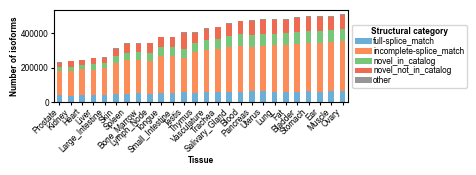

In [27]:
# The five minor categories are collapsed into a single "Other" segment: individually
# each is well under 1% of structures, so they were unreadable as separate slivers.
# structural_cat_order holds exactly these five after FSM/ISM/NIC/NNC, and tissue_cat_df
# is NOT modified -- the cells below still need the categories kept apart.
OTHER_CATS = ["fusion", "genic", "intergenic", "moreJunctions", "antisense"]
MAIN_CATS = [c for c in structural_cat_order if c not in OTHER_CATS]

_present = [c for c in OTHER_CATS if c in tissue_cat_df.columns]
plot_cat_df = tissue_cat_df[MAIN_CATS].copy()
plot_cat_df["other"] = tissue_cat_df[_present].sum(axis=1)
print(f"merged into Other: {', '.join(_present)}  "
      f"({plot_cat_df['other'].sum():,} isoform-tissue observations, "
      f"{plot_cat_df['other'].sum() / plot_cat_df.to_numpy().sum():.2%} of total)")

# "Other" has no entry in STRUCT_CAT_COLORS, and struct_cat_palette() falls back to
# black, which would dominate the bar. Give it a neutral grey instead.
plot_colors = struct_cat_palette(MAIN_CATS) + ["#969696"]

fig, ax = plt.subplots(figsize=(3.8, 1.2))
plot_cat_df.plot(kind="bar", stacked=True, ax=ax, color=plot_colors)
ax.set_xlabel("Tissue")
ax.set_ylabel("Number of isoforms")
plt.xticks(rotation=45, ha="right")
ax.legend(bbox_to_anchor=(1.00, 0.5), loc=6, title="Structural category")
plt.savefig(figpath("03_01_structural_category.pdf"))
plt.show()

In [28]:
# Normalize to proportions
tissue_cat_df_norm = tissue_cat_df.div(tissue_cat_df.sum(axis=1), axis=0)

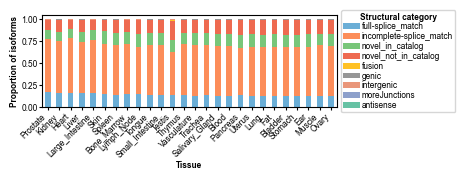

In [29]:
fig, ax = plt.subplots(figsize=(3.8, 1.2))
tissue_cat_df_norm.plot(kind="bar", stacked=True, ax=ax, color=struct_cat_palette(tissue_cat_df_norm.columns))
ax.set_xlabel("Tissue")
ax.set_ylabel("Proportion of isoforms")
ax.legend(bbox_to_anchor=(1.00, 0.5), loc=6, title="Structural category")
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("03_01_structural_category_normalized.pdf"))
plt.show()

In [30]:
# Per-tissue breakdown: pbids, ensemblids, and ensemblids_annotatedonly (>= 1 cell per tissue)
# Molecules = unique PB IDs; Transcripts = unique transcript_ids (ENST or PB); Isoforms = unique ENST IDs
# Stacked components are additive: isoforms + novel transcripts + redundant molecules = total molecules
mol_trans_iso = {}
for tissue in tissues:
    tissue_mask = adata_filt.obs["tissue"] == tissue
    if tissue_mask.sum() == 0:
        continue
    tissue_cell_counts = np.array((adata_filt.X[tissue_mask.values, :] > 0).sum(axis=0)).ravel()
    tissue_expressed = tissue_cell_counts >= 1

    n_molecules = int(tissue_expressed.sum())
    expressed_tids = adata_filt.var.loc[tissue_expressed, "transcript_id"]
    unique_tids = expressed_tids.unique()
    n_transcripts = len(unique_tids)
    enst_mask = pd.Series(unique_tids).str.startswith("ENST")
    n_isoforms = int(enst_mask.sum())

    mol_trans_iso[tissue] = {
        # "Unique molecules" : n_molecules,
        # "Unique transcripts":  n_transcripts,
        "Redundant molecules": n_molecules - n_transcripts,
        "Known isoforms (ENST)": n_isoforms,
        "Novel transcripts": n_transcripts - n_isoforms,
    }

mti_df = pd.DataFrame(mol_trans_iso).T
mti_df = mti_df.loc[mti_df.sum(axis=1).sort_values(ascending=False).index]

# Unique totals across all tissues: each pbids/ensemblids/ensemblids_annotatedonly counted ONCE
# (globally detected in >= 1 cell), not summed per tissue.
_glob_expr = np.array((adata_filt.X > 0).sum(axis=0)).ravel() >= 1
_u_mol = int(_glob_expr.sum())
_u_tids = adata_filt.var.loc[_glob_expr, "transcript_id"].unique()
_u_trans = len(_u_tids)
_u_iso = int(pd.Series(_u_tids).str.startswith("ENST").sum())
print(f"Total across all tissues (unique):")
print(f"  Molecules:          {_u_mol:,}")
print(f"  Known isoforms:     {_u_iso:,}")
print(f"  Novel transcripts:  {_u_trans - _u_iso:,}")
print(f"  Redundant molecules: {_u_mol - _u_trans:,}")

Total across all tissues (unique):
  Molecules:          854,410
  Known isoforms:     129,885
  Novel transcripts:  330,767
  Redundant molecules: 393,758


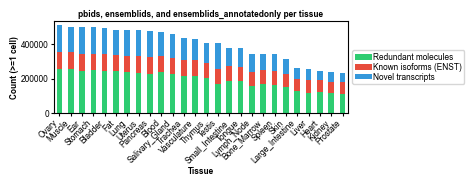

In [31]:
fig, ax = plt.subplots(figsize=(3.8, 1.2))
mti_df.plot(kind="bar", stacked=True, ax=ax, color=["#2ecc71", "#e74c3c", "#3498db"])
ax.set_xlabel("Tissue")
ax.set_ylabel("Count (>=1 cell)")
ax.set_title("pbids, ensemblids, and ensemblids_annotatedonly per tissue")
ax.legend(bbox_to_anchor=(1.00, 0.5), loc=6)
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("03_01_molecules_transcripts_isoforms_per_tissue.pdf"))
plt.show()


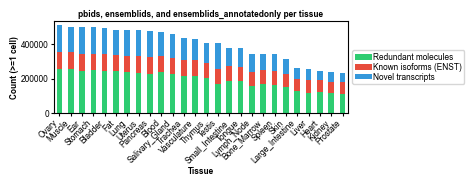

In [32]:
fig, ax = plt.subplots(figsize=(3.8, 1.2))
mti_df.plot(kind="bar", stacked=True, ax=ax, color=["#2ecc71", "#e74c3c", "#3498db"])
ax.set_xlabel("Tissue")
ax.set_ylabel("Count (>=1 cell)")
ax.set_title("pbids, ensemblids, and ensemblids_annotatedonly per tissue")
ax.legend(bbox_to_anchor=(1.00, 0.5), loc=6)
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("03_01_molecules_transcripts_isoforms_per_tissue.pdf"))
plt.show()

#4. Per-tissue novel isoform fraction (% NIC + NNC)

In [33]:
# Number of novel isoforms (NIC + NNC) per tissue, split by structural category
novel_cats = [c for c in structural_cat_order if c in {"novel_in_catalog", "novel_not_in_catalog"}]

novel_count_df = tissue_cat_df.reindex(columns=novel_cats, fill_value=0)
novel_count_df = novel_count_df.loc[novel_count_df.sum(axis=1).sort_values(ascending=False).index]

total_novel = novel_count_df.sum(axis=1)
_glob_expr_n = np.array((adata_filt.X > 0).sum(axis=0)).ravel() >= 1
_u_novel = int((adata_filt.var["pigeon_structural_category"].isin(novel_cats).values & _glob_expr_n).sum())
print(f"Total novel isoforms across tissues (unique): {_u_novel:,}")
print(f"Mean per tissue: {total_novel.mean():,.0f}, Median: {total_novel.median():,.0f}")

Total novel isoforms across tissues (unique): 321,443
Mean per tissue: 114,506, Median: 122,916


In [34]:
# --- Manuscript summary: known vs novel isoform structures recovered across tissues ---
# Known structures = FSM + ISM molecule models; annotated isoforms = the unique reference
# transcripts they map to (associated_transcript); novel = NIC + NNC. The per-tissue mean
# counts novel isoforms detected (>= 1 cell) within each tissue.
_sc = adata_filt.var["pigeon_structural_category"].astype(str)
_KNOWN = {"full-splice_match", "incomplete-splice_match"}
_NOVEL = {"novel_in_catalog", "novel_not_in_catalog"}
_known_mask = _sc.isin(_KNOWN).values
_novel_mask = _sc.isin(_NOVEL).values

n_known_structures = int(_known_mask.sum())                     # FSM + ISM isoform models
_at = adata_filt.var["pigeon_associated_transcript"].astype(str)
n_annotated = int(_at[_known_mask & ~_at.isin(["novel", "nan", ""])].nunique())  # reference transcripts they map to
n_novel = int(_novel_mask.sum())                                # NIC + NNC isoform models

# novel isoforms detected (>= 1 cell) within each tissue -> per-tissue mean
novel_per_tissue = {}
for tissue in tissues:
    tm = (adata_filt.obs["tissue"] == tissue).values
    if tm.sum() == 0:
        continue
    det = np.array((adata_filt.X[tm, :] > 0).sum(axis=0)).ravel() >= 1
    novel_per_tissue[tissue] = int((det & _novel_mask).sum())
novel_per_tissue = pd.Series(novel_per_tissue)
mean_novel = novel_per_tissue.mean()

print(
    f"Across tissues, we recovered {n_known_structures:,} known transcript structures "
    f"(FSM and ISM) mapping to {n_annotated:,} previously annotated isoforms. "
    f"We also recovered {n_novel:,} novel isoforms (NIC and NNC), where every tissue "
    f"contributed thousands of novel isoforms with a mean of {mean_novel:,.0f} per tissue "
    f"(range {int(novel_per_tissue.min()):,}\u2013{int(novel_per_tissue.max()):,})."
)

Across tissues, we recovered 520,216 known transcript structures (FSM and ISM) mapping to 129,557 previously annotated isoforms. We also recovered 321,443 novel isoforms (NIC and NNC), where every tissue contributed thousands of novel isoforms with a mean of 114,506 per tissue (range 49,076–151,093).


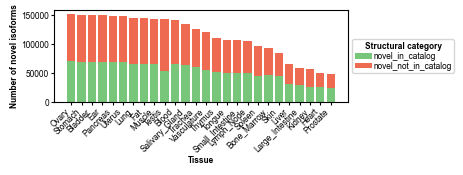

In [35]:
fig, ax = plt.subplots(figsize=(3.8, 1.2))
bottom = np.zeros(len(novel_count_df))
for c in novel_cats:
    ax.bar(novel_count_df.index, novel_count_df[c].values, bottom=bottom,
           color=STRUCT_CAT_COLORS[c], label=c, width=0.8, linewidth=0)
    bottom += novel_count_df[c].values
ax.set_ylabel("Number of novel isoforms")
ax.set_xlabel("Tissue")
ax.legend(title="Structural category", loc = 6, bbox_to_anchor = (1.0, 0.5))
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("03_01_novel_across_tissues.pdf"))
plt.show()

In [36]:
# Per-tissue fraction of novel isoforms, split into NIC vs NNC (stacked = total novel fraction)
novel_cats = [c for c in structural_cat_order if c in {"novel_in_catalog", "novel_not_in_catalog"}]

totals = tissue_cat_df.sum(axis=1)
novel_frac_df = tissue_cat_df.reindex(columns=novel_cats, fill_value=0).div(totals, axis=0)
novel_frac_df = novel_frac_df.loc[novel_frac_df.sum(axis=1).sort_values(ascending=False).index]
mean_total = novel_frac_df.sum(axis=1).mean()

In [37]:
novel_frac_df

pigeon_structural_category,novel_in_catalog,novel_not_in_catalog
Testis,0.132472,0.220643
Pancreas,0.147342,0.164947
Uterus,0.146081,0.162227
Bladder,0.139296,0.164521
Stomach,0.137951,0.165129
Lymph_Node,0.145232,0.157560
Lung,0.135344,0.166394
Ear,0.139781,0.161447
Fat,0.137206,0.162293
Blood,0.139986,0.157904


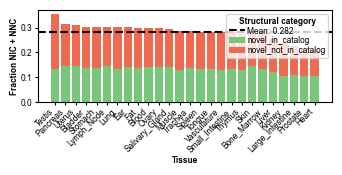

In [38]:
fig, ax = plt.subplots(figsize=(3.8, 1.2))
bottom = np.zeros(len(novel_frac_df))
for c in novel_cats:
    ax.bar(novel_frac_df.index, novel_frac_df[c].values, bottom=bottom,
           color=STRUCT_CAT_COLORS[c], label=c, width=0.8, linewidth=0)
    bottom += novel_frac_df[c].values
ax.set_xlabel("Tissue")
ax.set_ylabel("Fraction NIC + NNC")
# ax.set_title("Novel isoform fraction per tissue")
ax.axhline(mean_total, color="black", linestyle="--", label=f"Mean: {mean_total:.3f}")
ax.legend(title="Structural category")
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("03_01_novel_fraction_per_tissue.pdf"))
plt.show()


[All samples] novel isoforms: 321,443 | 1 sample 2.9% | >=2 97.1% | median 10 | max 60 of 60
[All samples]   known (FSM+ISM) reference: 520,216 isoforms | 1 sample 1.2% | >=2 98.8% | median 17


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


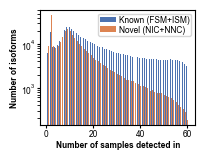

[All samples]   known vs novel, 1 sample only: 1.2% known vs 2.9% novel | median samples 17 known vs 10 novel


In [39]:
# === 4b. Novel isoform sample breadth ===
# Isoform-level analogue of the novel-JUNCTION breadth panel in 03_02 (section 2b).
# Per novel isoform (NIC + NNC): the number of distinct samples (tube_id) it is
# detected in, where "detected" is >= 1 count in >= 1 cell of that sample -- the same
# per-tissue detection rule used by the stacked-bar cells above. Testis contributes by
# far the most novel isoforms, so the distribution is also shown with testis excluded.
# Each subset is its OWN figure (was a 1x2 grid) so the panels can be placed separately.
_tube = adata_filt.obs["tube_id"].astype("category")
_tube_cats = list(_tube.cat.categories)
_tube_codes = _tube.cat.codes.values

# Detection matrix (samples x isoforms). Built with one CSR row-slice per sample rather
# than binarizing the whole matrix, so peak memory stays low; the bool result is only
# n_samples x n_vars (60 x 854,410 ~ 51 MB). Reused if already in the kernel, so
# re-running this cell to adjust the plots skips the full-matrix pass (`del detected`
# to force a recompute).
if "detected" in globals() and getattr(detected, "shape", None) == (len(_tube_cats), adata_filt.n_vars):
    print("reusing existing `detected` matrix")
else:
    detected = np.zeros((len(_tube_cats), adata_filt.n_vars), dtype=bool)
    for _i in range(len(_tube_cats)):
        _m = _tube_codes == _i
        if not _m.any():
            continue
        detected[_i] = np.asarray((adata_filt.X[_m, :] > 0).sum(axis=0)).ravel() >= 1

# sample -> tissue map, used to build the testis-excluded view
_tube_tissue = (adata_filt.obs[["tube_id", "tissue"]].astype(str)
                .drop_duplicates("tube_id").set_index("tube_id")["tissue"])
_is_testis_sample = np.array([
    "testis" in str(_tube_tissue.get(t, "")).lower() for t in _tube_cats])

_sc_b = adata_filt.var["pigeon_structural_category"].astype(str).values
_novel_b = np.isin(_sc_b, ["novel_in_catalog", "novel_not_in_catalog"])
_known_b = np.isin(_sc_b, ["full-splice_match", "incomplete-splice_match"])

# Known vs novel colours follow 04_01's convention for this exact contrast, so the two
# notebooks' known/novel panels can be read side by side.
KNOWN_COLOR, NOVEL_COLOR = "#4c72b0", "#dd8452"

subsets = [("All samples", "all_samples", np.ones(len(_tube_cats), dtype=bool)),
           # COMMENTED OUT: testis-excluded view. Re-enable to restore it.
           # ("Excluding testis", "excluding_testis", ~_is_testis_sample),
           ]

breadth = {}
for title, slug, smask in subsets:
    n_per_iso = detected[smask].sum(axis=0)      # samples each isoform is detected in
    N = int(smask.sum())
    nsamp = n_per_iso[_novel_b & (n_per_iso > 0)]    # novel isoforms seen in >= 1 kept sample
    breadth[title] = nsamp
    dist = pd.Series(nsamp).value_counts().sort_index()

    # COMMENTED OUT: novel-only panel, superseded by the known-vs-novel version below.
    # NOTE this basename is Supp Fig 3B in the panel map, so while this stays commented the
    # mapped panel is NOT regenerated -- the PDF already on disk is what remains. Either
    # re-enable this block or remap Supp Fig 3B to the known-vs-novel figure.
    # fig, ax = plt.subplots(figsize=(2.0, 1.2))
    # ax.bar(dist.index, dist.values, width=0.9, color="#c44e52")
    # ax.set_yscale("log")   # heavy right-skew: many novel isoforms are in a single sample
    # ax.set_xlabel("Number of samples detected in")
    # ax.set_ylabel("Number of novel isoforms")
    # ax.set_title(f"{title}\n({len(nsamp):,} novel isoforms, {N} samples)", pad=PANEL_TITLE_PAD)
    # plt.savefig(figpath(f"03_01_novel_isoform_sample_breadth_{slug}.pdf"),
    #             bbox_inches="tight", dpi=300)
    # plt.show()

    print(f"[{title}] novel isoforms: {len(nsamp):,} | 1 sample {(nsamp == 1).mean():.1%} | "
          f">=2 {(nsamp >= 2).mean():.1%} | median {np.median(nsamp):.0f} | "
          f"max {nsamp.max()} of {N}")
    # Known (FSM + ISM) reference for the same statistic -- printed only, not plotted.
    ksamp = n_per_iso[_known_b & (n_per_iso > 0)]
    print(f"[{title}]   known (FSM+ISM) reference: {len(ksamp):,} isoforms | "
          f"1 sample {(ksamp == 1).mean():.1%} | >=2 {(ksamp >= 2).mean():.1%} | "
          f"median {np.median(ksamp):.0f}")

    # --- same statistic, KNOWN and NOVEL side by side -----------------------------
    # The panel above shows novel isoforms alone; the known arm was computed for the
    # printed reference only. Here both are drawn on one axis so the shapes can be
    # compared directly -- the point being that known isoforms sit far to the right
    # (detected in most samples) while novel ones pile up at low sample counts.
    #
    # GROUPED, not stacked or overlaid: the two arms differ by roughly an order of
    # magnitude at every x, so a stack would render the novel arm invisible and an
    # alpha overlay would make the smaller counts ambiguous. Both bars share the log
    # y axis of the novel-only panel, so heights remain comparable across figures.
    #
    # A NEW BASENAME. 03_01_novel_isoform_sample_breadth_{slug}.pdf is a mapped panel
    # (Supp. Fig. 3B); writing this figure to that name would silently replace it.
    _x = np.arange(1, N + 1)
    _kv = pd.Series(ksamp).value_counts().sort_index().reindex(_x, fill_value=0).values
    _nv = dist.reindex(_x, fill_value=0).values

    fig, ax = plt.subplots(figsize=(2.0, 1.5))
    _w = 0.42
    ax.bar(_x - _w / 2, _kv, width=_w, color=KNOWN_COLOR, label="Known (FSM+ISM)")
    ax.bar(_x + _w / 2, _nv, width=_w, color=NOVEL_COLOR, label="Novel (NIC+NNC)")
    ax.set_yscale("log")
    ax.set_xlabel("Number of samples detected in")
    ax.set_ylabel("Number of isoforms")
    # ax.set_title(f"{title}\n({len(ksamp):,} known, {len(nsamp):,} novel; {N} samples)",
    #              pad=PANEL_TITLE_PAD)
    leg = ax.legend(frameon=True, handletextpad=0.3, borderpad=0.2, loc="upper right")
    leg.get_title().set_fontweight("bold")
    plt.savefig(figpath(f"03_01_isoform_sample_breadth_known_vs_novel_{slug}.pdf"),
                bbox_inches="tight", dpi=300)
    plt.show()

    print(f"[{title}]   known vs novel, 1 sample only: "
          f"{(ksamp == 1).mean():.1%} known vs {(nsamp == 1).mean():.1%} novel | "
          f"median samples {np.median(ksamp):.0f} known vs {np.median(nsamp):.0f} novel")

#5. Exon count and transcript length distributions by category (violin plots)

In [40]:
plot_df = adata_filt.var[["pigeon_structural_category", "pigeon_exons", "pigeon_length"]].dropna(subset=["pigeon_structural_category"]).copy()
plot_df["pigeon_exons"] = pd.to_numeric(plot_df["pigeon_exons"], errors="coerce")
plot_df["pigeon_length"] = pd.to_numeric(plot_df["pigeon_length"], errors="coerce")
plot_df = plot_df.dropna()

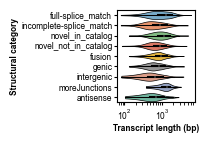

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(1.0, 1.2))
sns.violinplot(data=plot_df, y="pigeon_structural_category", x="pigeon_length", order=structural_cat_order,
               cut=0, ax=ax, scale="width", palette=STRUCT_CAT_COLORS,
               linecolor="black", linewidth=0.5,
               inner="box", inner_kws={"box_width": 1.5, "whis_width": 0.75})
ax.set_xlabel("Transcript length (bp)")
ax.set_ylabel("Structural category")
ax.set_xscale("log")
plt.savefig(figpath("03_01_Tx_length_by_structural.pdf"))
plt.show()

#5b. Exon count and transcript length as stacked bars (transcript counts, structural category as hue)

In [42]:
# Stacked histograms: transcript counts vs. exon number (LINEAR x) / transcript length (LOG x), structural category as hue.
# Reusing plot_df from the previous cell.
from matplotlib.ticker import NullFormatter

cats = list(structural_cat_order)                       # structural-category stacking order
colors = struct_cat_palette(cats)

# --- Exon counts: LINEAR x, integer bins; top bin catches EXON_CAP+ ---
EXON_CAP = 15
exon_vals = plot_df["pigeon_exons"].clip(lower=1, upper=EXON_CAP)
exon_bins = np.arange(0.5, EXON_CAP + 1.5, 1)     # integer-centered bins
exon_data = [exon_vals[plot_df["pigeon_structural_category"] == c].values for c in cats]

# --- Transcript length: LOG x, log-spaced bins; top bin catches >= LEN_MAX ---
LEN_MAX = 6000
N_LEN_BINS = 50
len_vals = plot_df["pigeon_length"].clip(upper=LEN_MAX)
len_lo = max(1.0, float(np.floor(len_vals[len_vals > 0].min())))
len_bins = np.logspace(np.log10(len_lo), np.log10(LEN_MAX), N_LEN_BINS)
len_data = [len_vals[plot_df["pigeon_structural_category"] == c].values for c in cats]


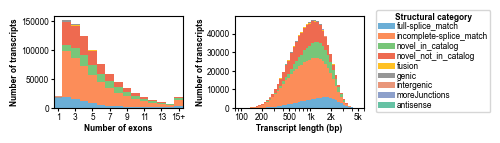

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(4.0, 1.2))

axes[0].hist(exon_data, bins=exon_bins, stacked=True, color=colors, label=cats)
axes[0].set_xlabel("Number of exons")
axes[0].set_ylabel("Number of transcripts")
axes[0].set_xlim(exon_bins[0], exon_bins[-1])
axes[0].set_xticks(list(range(1, EXON_CAP + 1, 2)))
axes[0].set_xticklabels([str(i) for i in range(1, EXON_CAP, 2)] + [f"{EXON_CAP}+"])

axes[1].hist(len_data, bins=len_bins, stacked=True, color=colors, label=cats)
axes[1].set_xlabel("Transcript length (bp)")
axes[1].set_ylabel("Number of transcripts")
axes[1].set_xscale("log")
axes[1].set_xlim(len_bins[0], len_bins[-1])
len_ticks = [t for t in [100, 200, 500, 1000, 2000, 5000] if len_bins[0] <= t <= len_bins[-1]]
axes[1].set_xticks(len_ticks)
axes[1].set_xticklabels([f"{t // 1000}k" if t >= 1000 else str(t) for t in len_ticks])
axes[1].xaxis.set_minor_formatter(NullFormatter())

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="Structural category",
           bbox_to_anchor=(0.92, 0.5), loc="center left")

plt.subplots_adjust(wspace=0.4)
plt.savefig(figpath("03_01_exon_length_stacked_bars.pdf"))
plt.show()


In [44]:
# --- Per-category length and exon-count summary -------------------------------
# Nothing was printed for this panel before, so the manuscript sentence comparing ISM
# with FSM rested on reading the stacked histogram by eye. Computed from adata_filt.var
# directly and NOT from the binned arrays above, which are capped at EXON_CAP and
# clipped to len_bins and would bias the medians.
_v = adata_filt.var
_df = pd.DataFrame({
    "cat": _v["pigeon_structural_category"].astype(str),
    "sub": (_v["pigeon_subcategory"].astype(str)
            if "pigeon_subcategory" in _v.columns else ""),
    "length": pd.to_numeric(_v["pigeon_length"], errors="coerce"),
    "exons": pd.to_numeric(_v["pigeon_exons"], errors="coerce"),
})

_summ = (_df.groupby("cat")
            .agg(n=("length", "size"),
                 len_q1=("length", lambda s: s.quantile(.25)),
                 len_median=("length", "median"),
                 len_q3=("length", lambda s: s.quantile(.75)),
                 exons_q1=("exons", lambda s: s.quantile(.25)),
                 exons_median=("exons", "median"),
                 exons_q3=("exons", lambda s: s.quantile(.75)))
            .sort_values("n", ascending=False))
print("Transcript length (bp) and exon count by structural category\n")
print(_summ.to_string(float_format=lambda x: f"{x:,.0f}"))

# the specific FSM vs ISM comparison the manuscript sentence makes
if {"full-splice_match", "incomplete-splice_match"} <= set(_summ.index):
    _f, _i = _summ.loc["full-splice_match"], _summ.loc["incomplete-splice_match"]
    print(f"\nFSM vs ISM   median length {_f.len_median:,.0f} vs {_i.len_median:,.0f} bp"
          f"   |   median exons {_f.exons_median:,.0f} vs {_i.exons_median:,.0f}")
    print("  ISM shorter than FSM?      "
          f"{'YES' if _i.len_median < _f.len_median else 'NO'}")
    print("  ISM fewer exons than FSM?  "
          f"{'YES' if _i.exons_median < _f.exons_median else 'NO'}")
    print("  (the draft sentence for Supp. Fig. 3E asserts YES to both)")

# ISM subcategory breakdown. Intron-retention ISMs are the one subpopulation that could
# push length the other way, so they are worth seeing separately before quoting a median.
_ism = _df[_df["cat"] == "incomplete-splice_match"]
if len(_ism):
    print("\nISM by subcategory:")
    print(_ism.groupby("sub")
              .agg(n=("length", "size"), len_median=("length", "median"),
                   exons_median=("exons", "median"))
              .sort_values("n", ascending=False)
              .to_string(float_format=lambda x: f"{x:,.0f}"))


Transcript length (bp) and exon count by structural category

                              n  len_q1  len_median  len_q3  exons_q1  exons_median  exons_q3
cat                                                                                          
incomplete-splice_match  419760     573         924   1,413         3             4         7
novel_not_in_catalog     194010     606         882   1,273         3             4         6
novel_in_catalog         127433     803       1,168   1,627         4             6         8
full-splice_match        100456     795       1,296   1,902         2             3         6
fusion                     6760     701         963   1,358         3             4         6
genic                      3877     565         849   1,252         2             2         2
intergenic                 1739     434         681   1,092         1             1         1
antisense                   296     480         715   1,124         1             1         

#6. Coding vs non-coding breakdown by category

In [45]:
if "sqanti_coding" in adata_filt.var.columns:
    ct = pd.crosstab(adata_filt.var["pigeon_structural_category"], adata_filt.var["sqanti_coding"], margins=True)
    print(ct)
    ct_norm = pd.crosstab(adata_filt.var["pigeon_structural_category"], adata_filt.var["sqanti_coding"], normalize="index")
    # Sort by coding fraction (ascending so the highest ends up at the top of the horizontal bars)
    ct_norm = ct_norm.sort_values(ct_norm.columns[-1], ascending=True)
else:
    ct_norm = None
    print("'coding' column not found in adata.var")

if ct_norm is not None:
    coding_col = "coding"  # or True, if sqanti_coding is boolean
    coding_pct = (ct_norm[coding_col] * 100).round(2)
    print("Percent coding within each structural category:")
    print(coding_pct)

sqanti_coding               coding  non_coding     All
pigeon_structural_category                            
antisense                       39         257     296
full-splice_match            58252       42204  100456
fusion                        3685        3075    6760
genic                          811        3066    3877
incomplete-splice_match     331642       88118  419760
intergenic                     301        1438    1739
moreJunctions                   69          10      79
novel_in_catalog             94696       32737  127433
novel_not_in_catalog        104866       89144  194010
All                         594361      260049  854410
Percent coding within each structural category:
pigeon_structural_category
moreJunctions              87.34
incomplete-splice_match    79.01
novel_in_catalog           74.31
full-splice_match          57.99
fusion                     54.51
novel_not_in_catalog       54.05
genic                      20.92
intergenic                 17.31
a

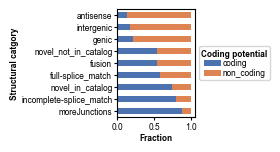

In [46]:
if ct_norm is not None:
    fig, ax = plt.subplots(figsize=(1.0, 1.4))
    ct_norm.plot(kind="barh", stacked=True, ax=ax, color=["#4c72b0", "#dd8452"])
    ax.set_xlabel("Fraction")
    ax.set_ylabel("Structural catgory")
    ax.legend(title="Coding potential", loc=6, bbox_to_anchor=(1.0, 0.5))
    plt.savefig(figpath("03_01_coding_potential_by_structural.pdf"))
    plt.show()


In [47]:
# Per-tissue coding vs non-coding counts (>= 1 cell per tissue)
novel_cats = {"novel_in_catalog", "novel_not_in_catalog"}
tissue_coding_all = {}
tissue_coding_novel = {}
for tissue in tissues:
    tissue_mask = adata_filt.obs["tissue"] == tissue
    if tissue_mask.sum() == 0:
        continue
    tissue_cell_counts = np.array((adata_filt.X[tissue_mask.values, :] > 0).sum(axis=0)).ravel()
    tissue_expressed = tissue_cell_counts >= 1

    var_sub = adata_filt.var.loc[tissue_expressed]
    coding_counts = var_sub["sqanti_coding"].value_counts()
    tissue_coding_all[tissue] = coding_counts

    var_novel = var_sub[var_sub["pigeon_structural_category"].isin(novel_cats)]
    tissue_coding_novel[tissue] = var_novel["sqanti_coding"].value_counts()

coding_all_df = pd.DataFrame(tissue_coding_all).fillna(0).astype(int).T
coding_all_df = coding_all_df.reindex(columns=["coding", "non_coding"], fill_value=0)
coding_all_df = coding_all_df.loc[coding_all_df.sum(axis=1).sort_values(ascending=False).index]

coding_novel_df = pd.DataFrame(tissue_coding_novel).fillna(0).astype(int).T
coding_novel_df = coding_novel_df.reindex(columns=["coding", "non_coding"], fill_value=0)
coding_novel_df = coding_novel_df.loc[coding_novel_df.sum(axis=1).sort_values(ascending=False).index]

coding_frac_all = coding_all_df["coding"].sum() / coding_all_df.sum().sum()
coding_frac_novel = coding_novel_df["coding"].sum() / coding_novel_df.sum().sum()

In [48]:
coding_all_df

sqanti_coding,coding,non_coding
Ovary,380950,127299
Muscle,366654,130870
Ear,365678,130564
Stomach,368945,126624
Bladder,368605,124238
Fat,359768,122858
Lung,357546,124412
Uterus,354150,124481
Pancreas,358521,114813
Blood,345678,126204


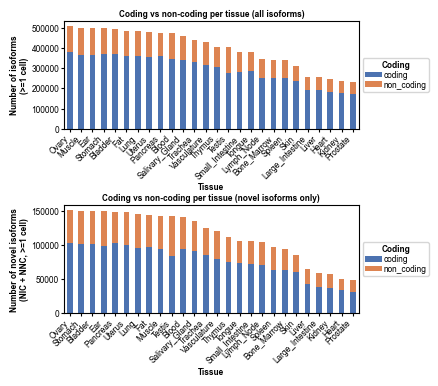

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(3.8, 3.8))

coding_all_df.plot(kind="bar", stacked=True, ax=axes[0], color=["#4c72b0", "#dd8452"])
axes[0].set_xlabel("Tissue")
axes[0].set_ylabel("Number of isoforms\n(>=1 cell)")
axes[0].set_title("Coding vs non-coding per tissue (all isoforms)")
axes[0].legend(title="Coding", bbox_to_anchor=(1.00, 0.5), loc=6)
axes[0].tick_params(axis="x", rotation=45)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

coding_novel_df.plot(kind="bar", stacked=True, ax=axes[1], color=["#4c72b0", "#dd8452"])
axes[1].set_xlabel("Tissue")
axes[1].set_ylabel("Number of novel isoforms\n(NIC + NNC, >=1 cell)")
axes[1].set_title("Coding vs non-coding per tissue (novel isoforms only)")
axes[1].legend(title="Coding", bbox_to_anchor=(1.00, 0.5), loc=6)
axes[1].tick_params(axis="x", rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha("right")

plt.subplots_adjust(hspace = 0.7)
plt.savefig(figpath("03_01_coding_per_tissue.pdf"))
plt.show()


#8. Novel isoform expression: FL counts for novel vs known

In [50]:
# Total counts per isoform
total_counts = np.array(adata_filt.X.sum(axis=0)).ravel()
adata_filt.var["total_counts"] = total_counts
adata_filt.var["n_cells"] = cell_counts_per_isoform[expressed_mask]

# Compare expression levels
known_cats = {"full-splice_match", "incomplete-splice_match"}
is_known = adata_filt.var["pigeon_structural_category"].isin(known_cats)
is_novel = adata_filt.var["pigeon_structural_category"].isin(novel_cats)
n_cells_arr = np.array(adata_filt.var["n_cells"])

print(f"Median total counts - Known: {np.median(total_counts[is_known]):.0f}, Novel: {np.median(total_counts[is_novel]):.0f}")
print(f"Median n_cells - Known: {np.median(n_cells_arr[is_known]):.0f}, Novel: {np.median(n_cells_arr[is_novel]):.0f}")


Median total counts - Known: 42, Novel: 21
Median n_cells - Known: 41, Novel: 20


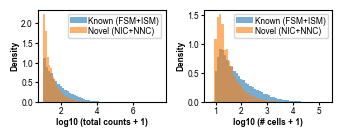

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(3.8, 1.2))

axes[0].hist(np.log10(total_counts[is_known] + 1), bins=50, alpha=0.6, label="Known (FSM+ISM)", density=True)
axes[0].hist(np.log10(total_counts[is_novel] + 1), bins=50, alpha=0.6, label="Novel (NIC+NNC)", density=True)
axes[0].set_xlabel("log10 (total counts + 1)")
axes[0].set_ylabel("Density")
# axes[0].set_title("Expression level: known vs novel")
axes[0].legend()

axes[1].hist(np.log10(n_cells_arr[is_known] + 1), bins=50, alpha=0.6, label="Known (FSM+ISM)", density=True)
axes[1].hist(np.log10(n_cells_arr[is_novel] + 1), bins=50, alpha=0.6, label="Novel (NIC+NNC)", density=True)
axes[1].set_xlabel("log10 (# cells + 1)")
axes[1].set_ylabel("Density")
# axes[1].set_title("Detection breadth: known vs novel")
axes[1].legend()

plt.subplots_adjust(wspace = 0.3)
plt.savefig(figpath("03_01_novel_vs_known_expression.pdf"))
plt.show()

#8b. Structural-category composition across observed transcript count
Bin isoforms by their **observed transcript count** (total molecule counts per isoform across all cells) and, within each bin, plot the **proportion** of isoforms in each pigeon structural category (stacked to 1.0, colored by category). The top panel shows the number of isoforms per bin. This reveals how the structural-category mix shifts with expression — novel isoforms (NIC/NNC) concentrate at low observed counts while full-splice matches dominate at high counts.

In [52]:
# Observed transcript count per isoform (total molecule counts across all cells)
obs_count = np.asarray(adata_filt.X.sum(axis=0)).ravel()
struct_cat = adata_filt.var["pigeon_structural_category"].astype(str).to_numpy()

# structural categories present, in the canonical order
cats_present = [c for c in structural_cat_order if c in set(struct_cat)]

# log-spaced bins over the observed-count range
N_BINS = 40
lo = max(obs_count.min(), 1)
hi = obs_count.max()
bin_edges = np.logspace(np.log10(lo), np.log10(hi + 1), N_BINS + 1)
bin_idx = np.clip(np.digitize(obs_count, bin_edges) - 1, 0, N_BINS - 1)

# per-bin isoform counts per structural category -> within-bin proportions
comp = pd.DataFrame(0.0, index=range(N_BINS), columns=cats_present)
for b in range(N_BINS):
    vc = pd.Series(struct_cat[bin_idx == b]).value_counts()
    for c in cats_present:
        comp.loc[b, c] = vc.get(c, 0)
n_per_bin = comp.sum(axis=1)
prop = comp.div(n_per_bin.replace(0, np.nan), axis=0).fillna(0.0)

print("Isoforms per observed-count bin:")
print(pd.DataFrame({"count_lo": bin_edges[:-1].round(0), "count_hi": bin_edges[1:].round(0),
                    "n_isoforms": n_per_bin.astype(int).values}).to_string(index=False))


Isoforms per observed-count bin:
  count_lo   count_hi  n_isoforms
      10.0       15.0      192586
      15.0       21.0      139184
      21.0       31.0       98718
      31.0       44.0       86375
      44.0       65.0       68042
      65.0       94.0       55062
      94.0      136.0       45437
     136.0      198.0       35922
     198.0      288.0       29268
     288.0      418.0       24042
     418.0      607.0       19277
     607.0      881.0       15211
     881.0     1280.0       11937
    1280.0     1859.0        9007
    1859.0     2699.0        6660
    2699.0     3921.0        4855
    3921.0     5694.0        3584
    5694.0     8270.0        2631
    8270.0    12012.0        1823
   12012.0    17446.0        1353
   17446.0    25338.0        1006
   25338.0    36800.0         699
   36800.0    53449.0         498
   53449.0    77628.0         372
   77628.0   112747.0         260
  112747.0   163753.0         182
  163753.0   237834.0         130
  237834.0   34

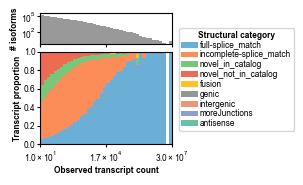

In [53]:
# top: # isoforms per count bin | bottom: stacked structural-category proportion.
# Shared x-axis (sharex) -> kept as a subplot grid, not split into separate figures.
fig, (axc, axp) = plt.subplots(2, 1, figsize=(1.7, 1.7), sharex=True,
                               gridspec_kw={"height_ratios": [1, 3]})

axc.bar(range(N_BINS), n_per_bin.values, width=1.0, color="#999999", linewidth=0)
axc.set_yscale("log")
axc.set_ylabel("# isoforms")

bottom = np.zeros(N_BINS)
for c in cats_present:
    y = prop[c].values
    axp.bar(range(N_BINS), y, bottom=bottom, width=1.0,
            color=STRUCT_CAT_COLORS.get(c, "#000000"), label=c, linewidth=0.5)
    bottom += y
axp.set_ylim(0, 1)
axp.set_xlim(-0.5, N_BINS - 0.5)
axp.set_ylabel("Transcript proportion")
axp.set_xlabel("Observed transcript count")

def _sci_label(v):
    """Format a value as mantissa x 10^exp, e.g. 1.2x10^2 (mathtext)."""
    if v <= 0:
        return "0"
    e = int(np.floor(np.log10(v)))
    m = v / 10 ** e
    return rf"${m:.1f}\times10^{{{e}}}$"

tick_pos = np.unique(np.linspace(0, N_BINS, 3).round().astype(int))   # 3 ticks: first / middle / last
axp.set_xticks(tick_pos - 0.5)
axp.set_xticklabels([_sci_label(bin_edges[i]) for i in tick_pos], rotation=0, ha="center")

axp.legend(title="Structural category", bbox_to_anchor=(1.02, 0.7), loc=6)
plt.subplots_adjust(hspace=0.12)
plt.savefig(figpath("03_01_structcat_proportion_vs_count.pdf"))
plt.show()
